<a href="https://colab.research.google.com/github/LamponeHub/System-Analysis/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%9F%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D0%B0_%D0%B3%D0%B8%D0%BF%D0%BE%D1%82%D0%B5%D0%B7_%D0%92%D0%B0%D1%80%D0%B3%D0%B0%D0%BD%D0%BE%D0%B2%D0%B0_%D0%9F_%D0%90%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Графики сохранены как 'statistical_analysis_results.png'


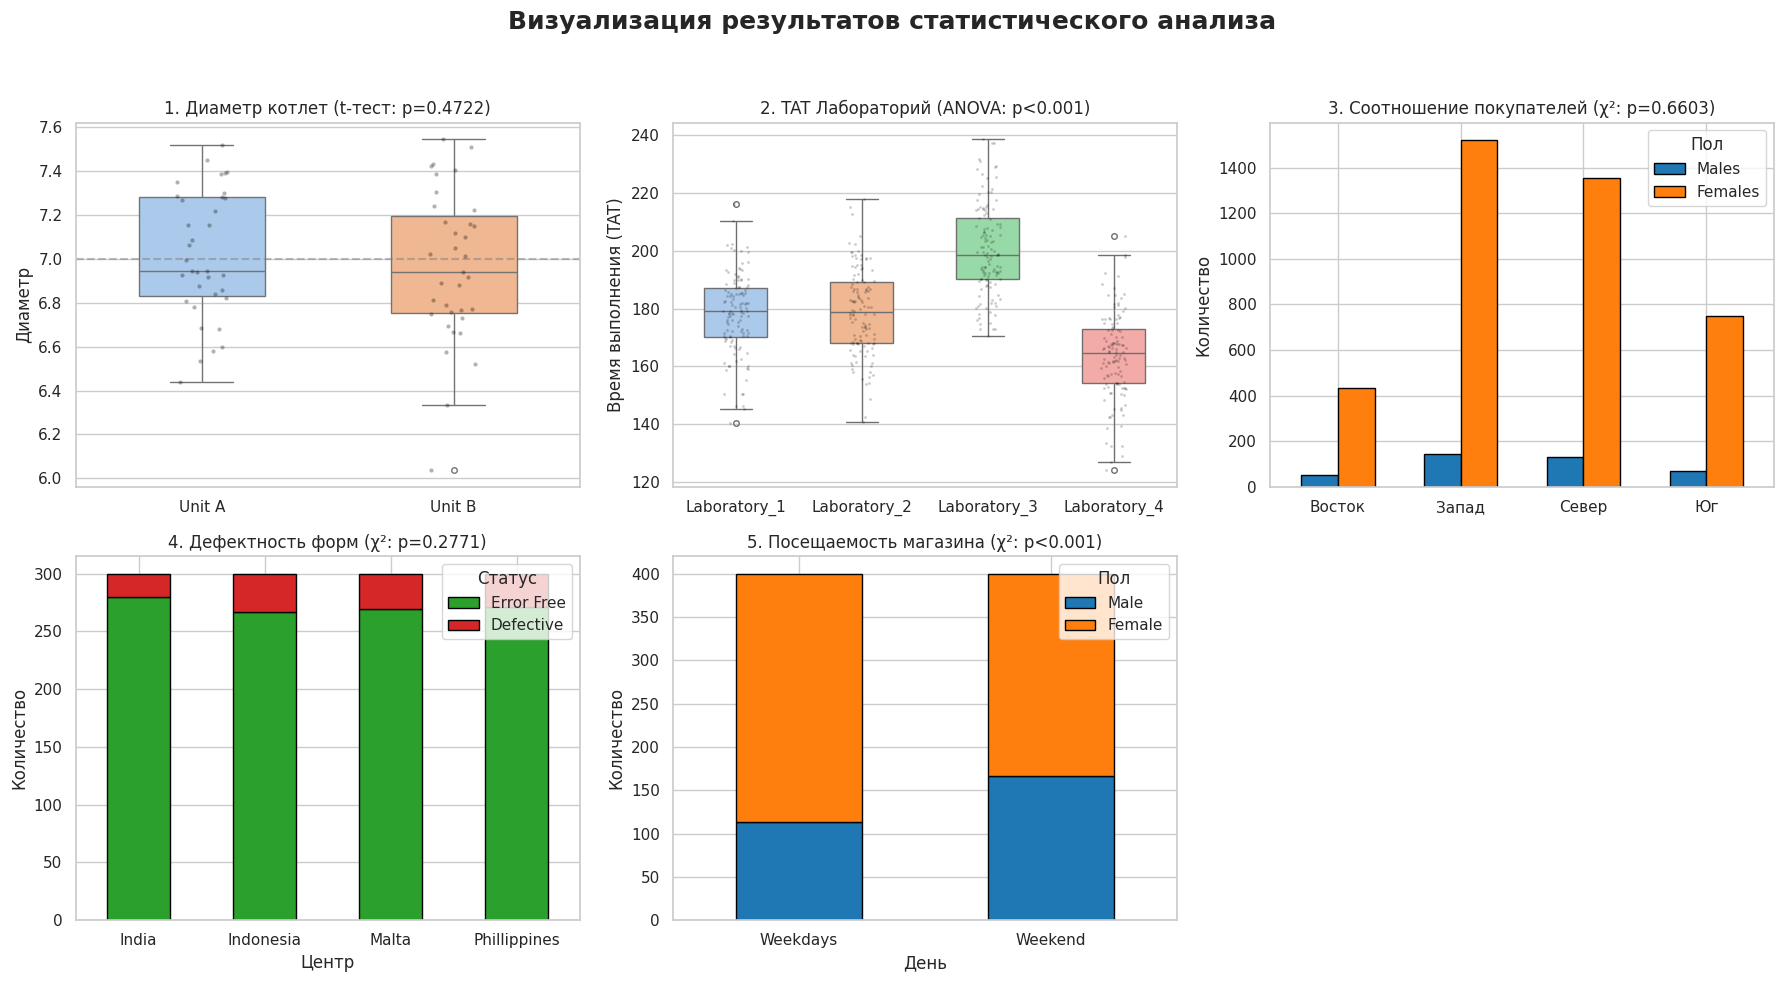

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Настройка стиля и шрифтов
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Визуализация результатов статистического анализа", fontsize=18, fontweight='bold', y=0.98)

# Вспомогательная функция для форматирования p-value
def fmt_p(p):
    return f"<0.001" if p < 0.001 else f"={p:.4f}"

# ==========================================
# 1. Cutlets.csv (t-тест Стьюдента)
# ==========================================
cutlets = pd.read_csv('Cutlets.csv').dropna()
ax1 = axes[0, 0]
sns.boxplot(data=cutlets, ax=ax1, width=0.5, flierprops=dict(marker='o', markersize=4))
sns.stripplot(data=cutlets, ax=ax1, color='black', alpha=0.3, jitter=True, size=3)
_, p1 = stats.ttest_ind(cutlets['Unit A'], cutlets['Unit B'])
ax1.set_title(f"1. Диаметр котлет (t-тест: p{fmt_p(p1)})")
ax1.set_ylabel("Диаметр")
ax1.set_xlabel("")
ax1.axhline(7.0, color='gray', linestyle='--', alpha=0.5)

# ==========================================
# 2. lab_tat_updated.csv (ANOVA)
# ==========================================
lab_tat = pd.read_csv('lab_tat_updated.csv').dropna()
ax2 = axes[0, 1]
sns.boxplot(data=lab_tat, ax=ax2, width=0.5, flierprops=dict(marker='o', markersize=4))
sns.stripplot(data=lab_tat, ax=ax2, color='black', alpha=0.2, jitter=True, size=2)
_, p2 = stats.f_oneway(*[lab_tat[col] for col in lab_tat.columns])
ax2.set_title(f"2. TAT Лабораторий (ANOVA: p{fmt_p(p2)})")
ax2.set_ylabel("Время выполнения (TAT)")
ax2.set_xlabel("")

# ==========================================
# 3. BuyerRatio.csv (Хи-квадрат)
# ==========================================
buyer = pd.read_csv('BuyerRatio.csv', index_col=0)
buyer.columns = ['Восток', 'Запад', 'Север', 'Юг']
ax3 = axes[0, 2]
buyer.T.plot(kind='bar', ax=ax3, color=['#1f77b4', '#ff7f0e'], edgecolor='black', width=0.6)
chi2_3, p3, _, _ = stats.chi2_contingency(buyer.values)
ax3.set_title(f"3. Соотношение покупателей (χ²: p{fmt_p(p3)})")
ax3.set_ylabel("Количество")
ax3.legend(title="Пол", loc='upper right')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)

# ==========================================
# 4. CustomerOrderform.csv (Хи-квадрат)
# ==========================================
order = pd.read_csv('CustomerOrderform.csv', skip_blank_lines=True)
order = order.dropna(subset=['Phillippines'])
order = order.apply(lambda col: col.astype(str).str.strip())
order_melt = order.melt(var_name='Центр', value_name='Статус')
cont4 = pd.crosstab(order_melt['Центр'], order_melt['Статус'])
cont4 = cont4.reindex(columns=['Error Free', 'Defective'], fill_value=0)
ax4 = axes[1, 0]
cont4.plot(kind='bar', stacked=True, ax=ax4, color=['#2ca02c', '#d62728'], edgecolor='black')
chi2_4, p4, _, _ = stats.chi2_contingency(cont4.values)
ax4.set_title(f"4. Дефектность форм (χ²: p{fmt_p(p4)})")
ax4.set_ylabel("Количество")
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.legend(title="Статус", loc='upper right')

# ==========================================
# 5. Fantaloons.csv (Хи-квадрат)
# ==========================================
fant = pd.read_csv('Fantaloons.csv', skip_blank_lines=True)
fant = fant.dropna(subset=['Weekdays'])
fant = fant.apply(lambda col: col.astype(str).str.strip())
fant_melt = fant.melt(var_name='День', value_name='Пол')
cont5 = pd.crosstab(fant_melt['День'], fant_melt['Пол'])
cont5 = cont5.reindex(columns=['Male', 'Female'], fill_value=0)
ax5 = axes[1, 1]
cont5.plot(kind='bar', stacked=True, ax=ax5, color=['#1f77b4', '#ff7f0e'], edgecolor='black')
chi2_5, p5, _, _ = stats.chi2_contingency(cont5.values)
ax5.set_title(f"5. Посещаемость магазина (χ²: p{fmt_p(p5)})")
ax5.set_ylabel("Количество")
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=0)
ax5.legend(title="Пол", loc='upper right')

# Скрываем неиспользуемый subplot
axes[1, 2].axis('off')

# Автоматическое выравнивание и сохранение/отображение
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("statistical_analysis_results.png", dpi=300, bbox_inches='tight')
print("✅ Графики сохранены как 'statistical_analysis_results.png'")
plt.show()

In [ ]:
from google.colab import files
import io

print("Please upload the following files: Cutlets.csv, lab_tat_updated.csv, BuyerRatio.csv, CustomerOrderform.csv, Fantaloons.csv")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Please upload the following files: Cutlets.csv, lab_tat_updated.csv, BuyerRatio.csv, CustomerOrderform.csv, Fantaloons.csv


Saving lab_tat_updated.csv to lab_tat_updated (2).csv
Saving Fantaloons.csv to Fantaloons (2).csv
Saving Cutlets.csv to Cutlets (2).csv
Saving CustomerOrderform.csv to CustomerOrderform (1).csv
Saving BuyerRatio.csv to BuyerRatio (1).csv
User uploaded file "lab_tat_updated (2).csv" with length 3491 bytes
User uploaded file "Fantaloons (2).csv" with length 5533 bytes
User uploaded file "Cutlets (2).csv" with length 573 bytes
User uploaded file "CustomerOrderform (1).csv" with length 13498 bytes
User uploaded file "BuyerRatio (1).csv" with length 87 bytes


Once the files are uploaded, you can re-run the previous cell to execute the statistical analysis.